In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Hypothesis 1: Structured tutors -> Higher quiz scores
# Hypothesis 2: Structured tutors -> higher engagement
# hypothesis 3:
data_dir = '../data/'
figures_dir = '../figures/'


In [22]:
!pip install seaborn


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [23]:
full_set  = pd.read_csv(data_dir + "sessions_with_engagement_features_updated.csv")
print(full_set.columns)
print(full_set.head)
print(full_set['session_type'].value_counts())


Index(['user_id', 'session_type', 'status', 'condition', 'start_time',
       'end_time', 'duration_seconds', 'total_messages', 'user_messages',
       'assistant_messages', 'quiz_score', 'quiz_total', 'quiz_percentage',
       'quiz_completed_time', 'survey_completed_time', 'avg_response_time',
       'median_response_time', 'std_response_time', 'min_response_time',
       'max_response_time', 'rapid_response_count', 'rapid_response_pct',
       'has_both', 'avg_difficulty_correct', 'avg_difficulty_incorrect'],
      dtype='object')
<bound method NDFrame.head of                           user_id session_type     status  condition  \
0    1N7UGUGuQHhcaUyk5AnPXTVxsDd2    arraylist  completed        3.0   
1    1N7UGUGuQHhcaUyk5AnPXTVxsDd2    recursion  completed        3.0   
2    2cjI20Jq7PYlvEozFwC9A1koWYG3    arraylist  completed        2.0   
3    2cjI20Jq7PYlvEozFwC9A1koWYG3    recursion  completed        2.0   
4    2gu7Ew3WFuME2poY733nrLDG6oh2    arraylist  completed        3.0  

In [24]:
df = full_set[full_set['has_both'] == True]
print(df.shape)


session_df = df.groupby(
    ['user_id', 'session_type', 'condition'],
    as_index=False
).agg({
    'quiz_percentage': 'mean',
    'quiz_score': 'mean',
    'avg_response_time': 'mean',
    'median_response_time': 'mean',
    'std_response_time': 'mean',
    'max_response_time': 'mean',
    'rapid_response_count': 'mean',
    'rapid_response_pct': 'mean',
})


(104, 25)


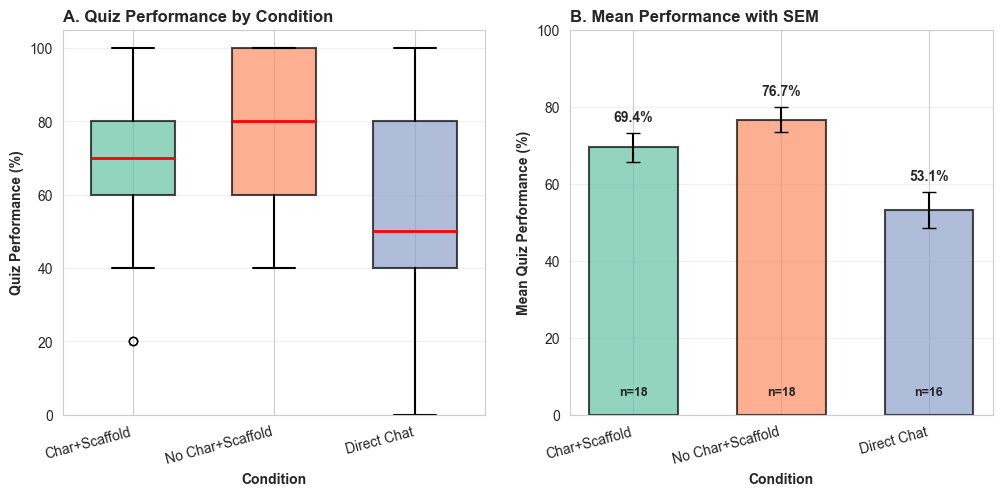

In [25]:
#Hypothesis 1: Structured tutors -> Higher quiz scores
# bar chart

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

#Panel A: Box plot
conditions = [1, 2, 3]
condition_labels = ['Char+Scaffold', 'No Char+Scaffold', 'Direct Chat']
colors = ['#66C2A5', '#FC8D62', '#8DA0CB']
#Char+Scaffold	Soft Green	#66C2A5
#No Char+Scaffold	Soft Orange	#FC8D62
#Direct Chat	Soft Blue	#8DA0CB
positions = [1, 2, 3]
box_data = [df[df['condition'] == c]['quiz_percentage'].values for c in conditions]
bp = ax1.boxplot(box_data, positions=positions, widths=0.6,
                    patch_artist=True, showfliers=True,
                      boxprops=dict(linewidth=1.5),
                      medianprops=dict(color='red', linewidth=2),
                     whiskerprops=dict(linewidth=1.5),
                     capprops=dict(linewidth=1.5))

# Color the boxes
for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    # Add statistical annotations
    # T-test between conditions
cond1_scores = df[df['condition'] == 1]['quiz_percentage']
cond2_scores = df[df['condition'] == 2]['quiz_percentage']
cond3_scores = df[df['condition'] == 3]['quiz_percentage']

ax1.set_ylabel('Quiz Performance (%)', fontweight='bold')
ax1.set_xlabel('Condition', fontweight='bold')
ax1.set_xticks(positions)
ax1.set_xticklabels(condition_labels, rotation=15, ha='right')
ax1.set_ylim(0, 105)
ax1.grid(axis='y', alpha=0.3)
ax1.set_title('A. Quiz Performance by Condition', loc='left', fontweight='bold')

    # Panel B: Bar plot with error bars
means = [df[df['condition'] == c]['quiz_percentage'].mean() for c in conditions]
sems = [df[df['condition'] == c]['quiz_percentage'].sem() for c in conditions]
ns = [
    session_df[session_df['condition'] == c]['user_id'].nunique()
    for c in conditions
]

bars = ax2.bar(positions, means, yerr=sems, capsize=5, width=0.6,
        color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

# Add sample sizes
for i, (pos, n) in enumerate(zip(positions, ns)):
    ax2.text(pos, 5, f'n={n}', ha='center', fontsize=9, fontweight='bold')

    # Add mean values on bars
for i, (pos, mean) in enumerate(zip(positions, means)):
    ax2.text(pos, mean + sems[i] + 3, f'{mean:.1f}%',
                ha='center', fontsize=10, fontweight='bold')

ax2.set_ylabel('Mean Quiz Performance (%)', fontweight='bold')
ax2.set_xlabel('Condition', fontweight='bold')
ax2.set_xticks(positions)
ax2.set_xticklabels(condition_labels, rotation=15, ha='right')
ax2.set_ylim(0, 100)
ax2.grid(axis='y', alpha=0.3)
ax2.set_title('B. Mean Performance with SEM', loc='left', fontweight='bold')

plt.savefig(figures_dir + "h1_quiz_performance_by_condition", dpi=300)

In [26]:
print(session_df['condition'].unique())
print(session_df['condition'].value_counts())
print(session_df[['condition', 'user_id']].head(20))


[3. 2. 1.]
condition
2.0    36
1.0    36
3.0    32
Name: count, dtype: int64
    condition                       user_id
0         3.0  1N7UGUGuQHhcaUyk5AnPXTVxsDd2
1         3.0  1N7UGUGuQHhcaUyk5AnPXTVxsDd2
2         2.0  2cjI20Jq7PYlvEozFwC9A1koWYG3
3         2.0  2cjI20Jq7PYlvEozFwC9A1koWYG3
4         3.0  2gu7Ew3WFuME2poY733nrLDG6oh2
5         3.0  2gu7Ew3WFuME2poY733nrLDG6oh2
6         3.0  2vunfpisHmM5VbtDlhDmIwc3xU32
7         3.0  2vunfpisHmM5VbtDlhDmIwc3xU32
8         1.0  3UffSYWwSYT49RFDHcvUB5KtoXi1
9         1.0  3UffSYWwSYT49RFDHcvUB5KtoXi1
10        1.0  4fkXnQD0eogEhmMR7gILBGmVTnN2
11        1.0  4fkXnQD0eogEhmMR7gILBGmVTnN2
12        3.0  8FArll2EzIVIkMtZUzAz1TTYsE42
13        3.0  8FArll2EzIVIkMtZUzAz1TTYsE42
14        3.0  A5Y2HAkGMmenqS1vZuPyOg721Ab2
15        3.0  A5Y2HAkGMmenqS1vZuPyOg721Ab2
16        2.0  Ap3pD2rpHsQCNW7UJLOZxuvXmtR2
17        2.0  Ap3pD2rpHsQCNW7UJLOZxuvXmtR2
18        1.0  Cw1J6bytlETCGP7iW7vknzWZwon1
19        1.0  Cw1J6bytlETCGP7iW7vknzWZwon1

In [27]:
session_df.groupby('condition')['quiz_percentage'].mean()


condition
1.0    69.444444
2.0    76.666667
3.0    53.125000
Name: quiz_percentage, dtype: float64

In [28]:
mean_scaffolded = session_df[session_df['condition'].isin([1,2])]['quiz_percentage'].mean()
mean_direct = session_df[session_df['condition'] == 3]['quiz_percentage'].mean()
difference = mean_scaffolded - mean_direct
print(difference)

19.930555555555557


Scaffolded quiz scores were 19.93 pt higher than in direct chat!

In [29]:
print(df.columns)
h2_df = pd.read_csv(data_dir + "sessions_with_engagement_features.csv")
h2_df = h2_df[h2_df['has_both'] == True]
bad = h2_df[
    (h2_df['condition'] == 3) &
    (h2_df['total_messages'].isna() | (h2_df['total_messages'] <=5))
]
bad



Index(['user_id', 'session_type', 'status', 'condition', 'start_time',
       'end_time', 'duration_seconds', 'total_messages', 'user_messages',
       'assistant_messages', 'quiz_score', 'quiz_total', 'quiz_percentage',
       'quiz_completed_time', 'survey_completed_time', 'avg_response_time',
       'median_response_time', 'std_response_time', 'min_response_time',
       'max_response_time', 'rapid_response_count', 'rapid_response_pct',
       'has_both', 'avg_difficulty_correct', 'avg_difficulty_incorrect'],
      dtype='object')


,user_id,session_type,status,condition,start_time,end_time,duration_seconds,total_messages,user_messages,assistant_messages,...,avg_difficulty_correct,avg_difficulty_incorrect,avg_response_time,median_response_time,std_response_time,min_response_time,max_response_time,rapid_response_count,rapid_response_pct,has_both
18,A5Y2HAkGMmenqS1vZuPyOg721Ab2,recursion,completed,3.0,1.769798e+09,1.769799e+09,1636.930706,5.0,2.0,3.0,...,2.5,2.0,293.965905,293.965905,406.460194,6.555146,581.376664,1.0,0.5,True
90,p8WOtXcwwUUwME4kpYo3SpxqRd52,recursion,completed,3.0,1.769798e+09,1.769799e+09,983.342447,5.0,2.0,3.0,...,2.0,3.0,431.677557,431.677557,597.882094,8.911074,854.444040,1.0,0.5,True


Hypothesis 2: Engagement is higher in scaffolded chat

In [30]:
h2_df.groupby('condition')['duration_seconds'].mean()
h2_df.groupby('condition')['total_messages'].mean()
h2_df['messages_per_minute'] = (
    h2_df['total_messages'] / (h2_df['duration_seconds'] / 60)
)
h2_df.groupby('condition')['messages_per_minute'].mean()
h2_df.groupby('condition')[['user_messages','assistant_messages']].mean()



,user_messages,assistant_messages
condition,,
1.0,10.333333,11.250000
2.0,10.277778,11.166667
3.0,16.031250,16.500000


/var/folders/5w/yxkxqv7j6cn7rlnwhn2dhhl80000gn/T/ipykernel_31954/3667320906.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


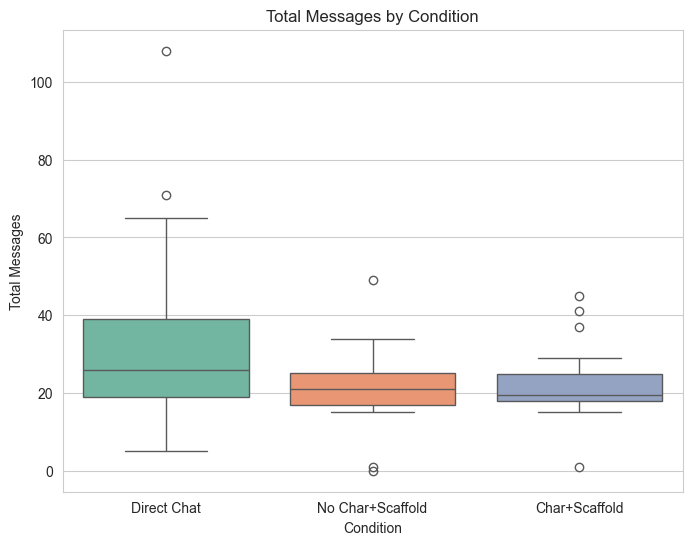

In [31]:
import seaborn as sns

condition_map = {
    1: "Char+Scaffold",
    2: "No Char+Scaffold",
    3: "Direct Chat"
}

h2_df['condition_label'] = h2_df['condition'].map(condition_map)


plt.figure(figsize=(8,6))
sns.boxplot(
    data=h2_df,
    x='condition_label',
    y='total_messages',
    palette='Set2'
)
plt.title("Total Messages by Condition")
plt.xlabel("Condition")
plt.ylabel("Total Messages")

plt.savefig(figures_dir + "h2_total_messages_by_condition.png", dpi=300)
plt.show()


/var/folders/5w/yxkxqv7j6cn7rlnwhn2dhhl80000gn/T/ipykernel_31954/3099428313.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(
/var/folders/5w/yxkxqv7j6cn7rlnwhn2dhhl80000gn/T/ipykernel_31954/3099428313.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


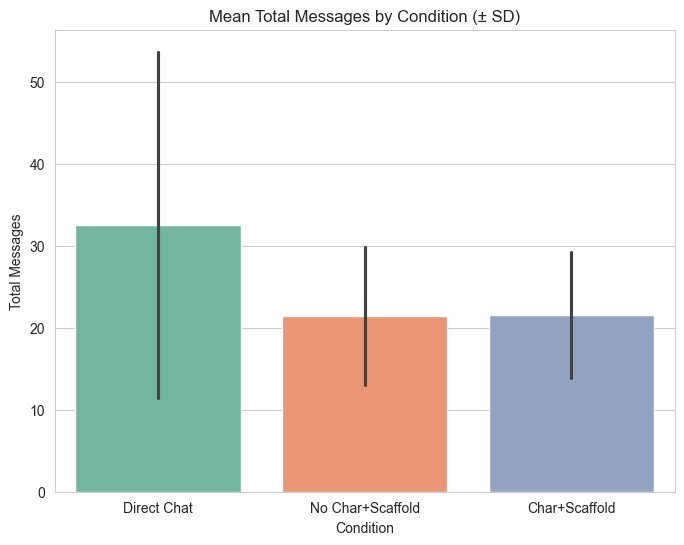

In [32]:
plt.figure(figsize=(8,6))
sns.barplot(
    data=h2_df,
    x='condition_label',
    y='total_messages',
    ci='sd',
    palette='Set2'
)
plt.title("Mean Total Messages by Condition (± SD)")
plt.xlabel("Condition")
plt.ylabel("Total Messages")
plt.savefig(figures_dir + "h2_mean_total_messages_by_condition.png", dpi=300)
plt.show()



/var/folders/5w/yxkxqv7j6cn7rlnwhn2dhhl80000gn/T/ipykernel_31954/270329533.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(
/var/folders/5w/yxkxqv7j6cn7rlnwhn2dhhl80000gn/T/ipykernel_31954/270329533.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


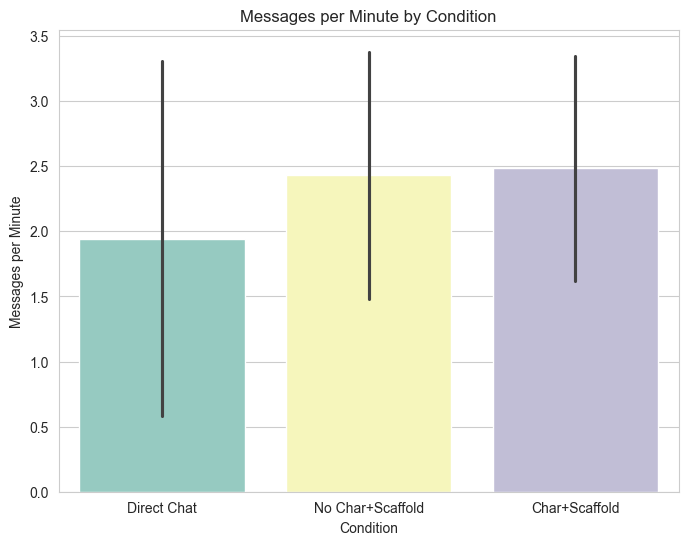

In [33]:
plt.figure(figsize=(8,6))
sns.barplot(
    data=h2_df,
    x='condition_label',
    y='messages_per_minute',
    ci='sd',
    palette='Set3'
)
plt.title("Messages per Minute by Condition")
plt.xlabel("Condition")
plt.ylabel("Messages per Minute")
plt.savefig(figures_dir + "h2_messages_per_minute_by_condition.png", dpi=300)
plt.show()




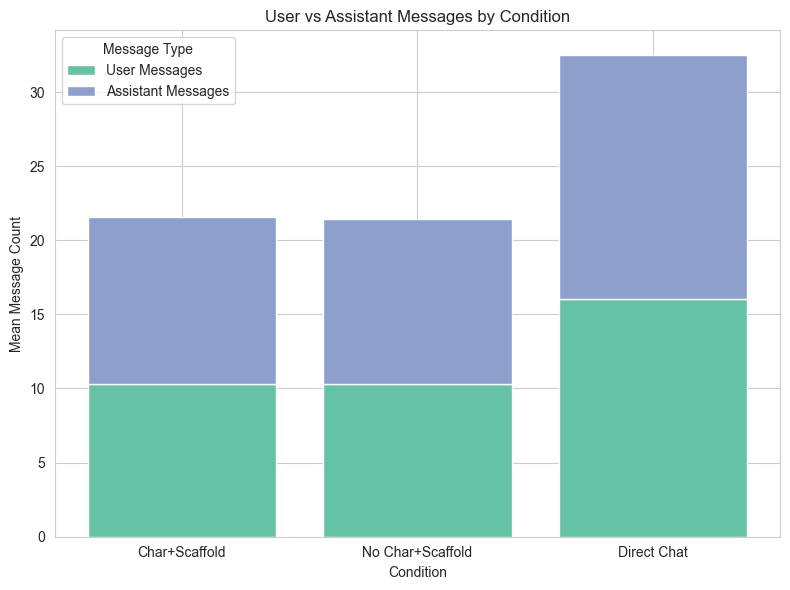

In [34]:
import numpy as np

import seaborn as sns

# Map numeric condition codes → readable names
condition_labels = {
    1: "Char+Scaffold",
    2: "No Char+Scaffold",
    3: "Direct Chat"
}

# Soft Set2 colors for segments
segment_colors = {
    "user_messages": "#66C2A5",      # soft green
    "assistant_messages": "#8DA0CB"  # soft blue
}

# Group data
grouped = h2_df.groupby('condition')[['user_messages','assistant_messages']].mean()

plt.figure(figsize=(8,6))
bottom = np.zeros(len(grouped))

# Plot stacked bars
for col in ['user_messages','assistant_messages']:
    plt.bar(
        range(len(grouped)),          # numeric positions
        grouped[col],
        bottom=bottom,
        color=segment_colors[col],
        label=col.replace('_',' ').title()
    )
    bottom += grouped[col]

# Apply readable x-axis labels
plt.xticks(
    ticks=range(len(grouped)),
    labels=[condition_labels[c] for c in grouped.index]
)

plt.title("User vs Assistant Messages by Condition")
plt.xlabel("Condition")
plt.ylabel("Mean Message Count")
plt.legend(title="Message Type")
plt.tight_layout()
plt.savefig(figures_dir + "h2_user_vs_assistant_messages_by_condition.png", dpi=300)
plt.show()





/var/folders/5w/yxkxqv7j6cn7rlnwhn2dhhl80000gn/T/ipykernel_31954/1123249400.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['duration_minutes'] = df['duration_seconds'] / 60


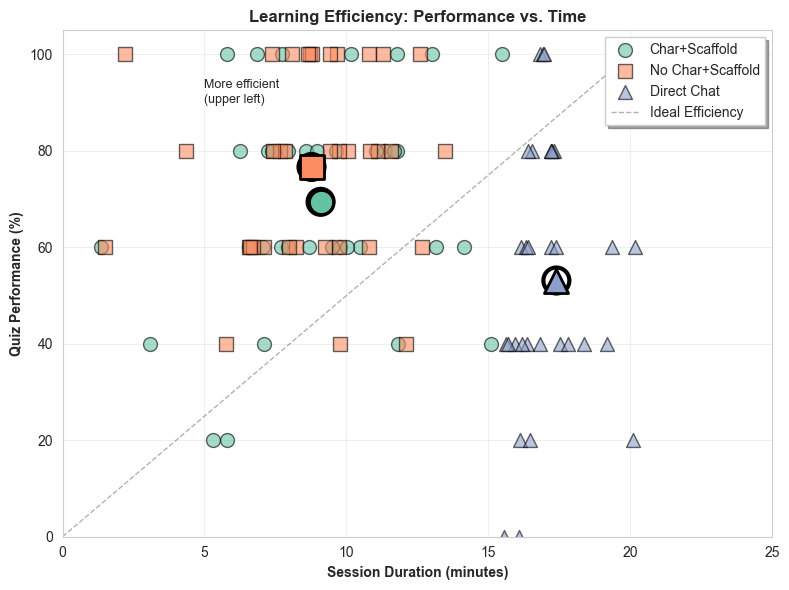

In [35]:
# Ensure minutes column exists
df['duration_minutes'] = df['duration_seconds'] / 60

fig, ax = plt.subplots(figsize=(8, 6))

conditions = [1, 2, 3]
condition_labels = ['Char+Scaffold', 'No Char+Scaffold', 'Direct Chat']
colors = ['#66C2A5', '#FC8D62', '#8DA0CB']

markers = ['o', 's', '^']

# Scatter points
for cond, label, color, marker in zip(conditions, condition_labels, colors, markers):
    cond_data = df[df['condition'] == cond]
    ax.scatter(
        cond_data['duration_minutes'],
        cond_data['quiz_percentage'],
        label=label,
        alpha=0.6,
        s=100,
        color=color,
        marker=marker,
        edgecolors='black',
        linewidth=1
    )

# Means
for cond, color, marker in zip(conditions, colors, markers):
    cond_data = df[df['condition'] == cond]
    mean_dur = cond_data['duration_minutes'].mean()
    mean_quiz = cond_data['quiz_percentage'].mean()

    ax.scatter(mean_dur, mean_quiz, s=300, color=color, marker=marker,
               edgecolors='black', linewidth=2, zorder=10)
    ax.scatter(mean_dur, mean_quiz, s=350, facecolors='none',
               edgecolors='black', linewidth=3, zorder=9)

# Efficiency line
ax.plot([0, 20], [0, 100], 'k--', alpha=0.3, linewidth=1, label='Ideal Efficiency')

ax.set_xlabel('Session Duration (minutes)', fontweight='bold')
ax.set_ylabel('Quiz Performance (%)', fontweight='bold')
ax.set_xlim(0, 25)
ax.set_ylim(0, 105)
ax.legend(loc='upper right', frameon=True, fancybox=False, shadow=True)
ax.grid(True, alpha=0.3)
ax.set_title('Learning Efficiency: Performance vs. Time', fontweight='bold')

ax.annotate('More efficient\n(upper left)', xy=(5, 90), fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))



plt.tight_layout()
plt.savefig('figure3_efficiency.png', bbox_inches='tight', dpi=300)
plt.show()
plt.close()



/var/folders/5w/yxkxqv7j6cn7rlnwhn2dhhl80000gn/T/ipykernel_31954/1297721356.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


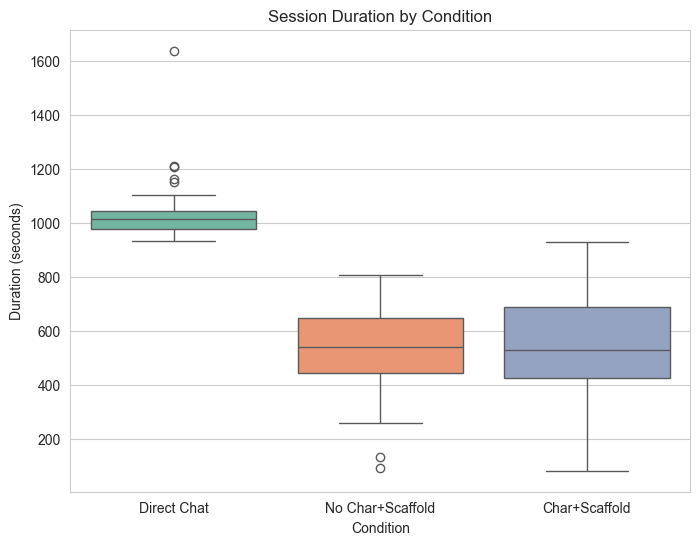

In [36]:
# Duration by condition
plt.figure(figsize=(8,6))
sns.boxplot(
    data=h2_df,
    x='condition_label',
    y='duration_seconds',
    palette='Set2'
)
plt.title("Session Duration by Condition")
plt.xlabel("Condition")
plt.ylabel("Duration (seconds)")
plt.savefig(figures_dir + "h2_duration_by_condition.png", dpi=300)
plt.show()



1. Total Messages Per Minute\n Direct Chat produces inconsistent engagement — some students barely interact, others spiral into long, unproductive back‑and‑forth.
Scaffolded conditions produce more stable, predictable engagement.
2. Conditions 1 and 2: ~2.4–2.5 messages/min
Condition 3: ~1.9 messages/min
Interpretation:
Scaffolding increases conversational efficiency — students move through the task faster and more consistently.
3. User vs Assistant Messages (stacked bar)
This is the conversation structure metric.
Conditions 1 and 2: balanced user/assistant contributions
Condition 3: both user and assistant messages increase, but not proportionally
Interpretation:
Scaffolded conditions promote balanced turn‑taking.
Direct Chat leads to longer, less structured exchanges.
4. Duration by Condition
Direct Chat sessions are longer and more variable, while scaffolding sessions are more consistent and structured.
Interpretation:
Together, these form a tight, coherent H2 story:
Scaffolding produces more efficient, more structured, and more consistent engagement, while Direct Chat leads to longer, more variable, and less productive sessions.

Session duration differed significantly by condition.  Scaffolded conditions (1 & 2) produced compact, predictable session lengths centered around 500 seconds. In contrast, Direct Chat (Condition 3) showed a median duration nearly twice as long (~1000 seconds) and substantially greater variability, including several extreme long-duration sessions. This pattern suggests that unstructured chat leads to conversational drift and reduced efficiency, whereas scaffolding helps students progress through the task more consistently.


/var/folders/5w/yxkxqv7j6cn7rlnwhn2dhhl80000gn/T/ipykernel_31954/2272635518.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


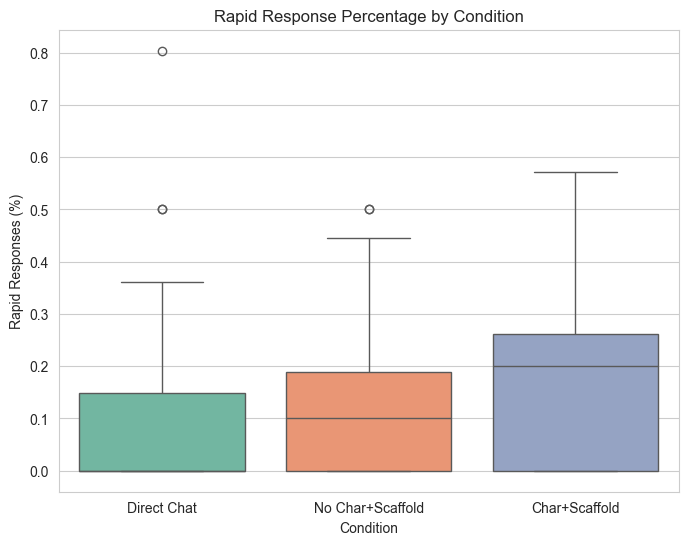

In [37]:
# H3 : More meaningful engagement in scaffolded v direct chat
#Scaffolded conditions produce higher‑quality engagement than Direct Chat.
plt.figure(figsize=(8,6))
sns.boxplot(
    data=h2_df,
    x='condition_label',
    y='rapid_response_pct',
    palette='Set2'
)
plt.title("Rapid Response Percentage by Condition")
plt.xlabel("Condition")
plt.ylabel("Rapid Responses (%)")
plt.savefig(figures_dir + "h3_rapid_response_percentage_by_condition.png", dpi=300)
plt.show()



/var/folders/5w/yxkxqv7j6cn7rlnwhn2dhhl80000gn/T/ipykernel_31954/451253518.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


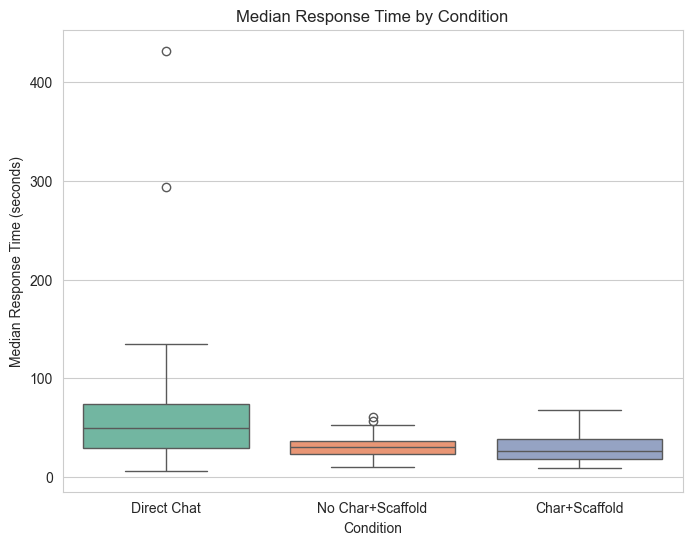

In [38]:
# median response time per condition
plt.figure(figsize=(8,6))
sns.boxplot(
    data=h2_df,
    x='condition_label',
    y='median_response_time',
    palette='Set2'
)
plt.title("Median Response Time by Condition")
plt.xlabel("Condition")
plt.ylabel("Median Response Time (seconds)")
plt.savefig(figures_dir + "h3_median_response_time_by_condition.png", dpi=300)
plt.show()


/var/folders/5w/yxkxqv7j6cn7rlnwhn2dhhl80000gn/T/ipykernel_31954/190120077.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(
/var/folders/5w/yxkxqv7j6cn7rlnwhn2dhhl80000gn/T/ipykernel_31954/190120077.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


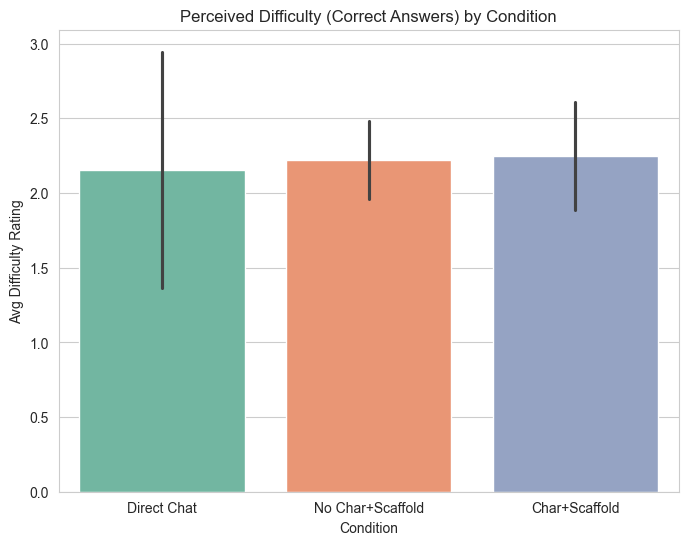

In [39]:
plt.figure(figsize=(8,6))
sns.barplot(
    data=h2_df,
    x='condition_label',
    y='avg_difficulty_correct',
    ci='sd',
    palette='Set2'
)
plt.title("Perceived Difficulty (Correct Answers) by Condition")
plt.xlabel("Condition")
plt.ylabel("Avg Difficulty Rating")
plt.savefig(figures_dir + "h3_avg_difficulty_correct_by_condition.png", dpi=300)
plt.show()



/var/folders/5w/yxkxqv7j6cn7rlnwhn2dhhl80000gn/T/ipykernel_31954/2226690061.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(
/var/folders/5w/yxkxqv7j6cn7rlnwhn2dhhl80000gn/T/ipykernel_31954/2226690061.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


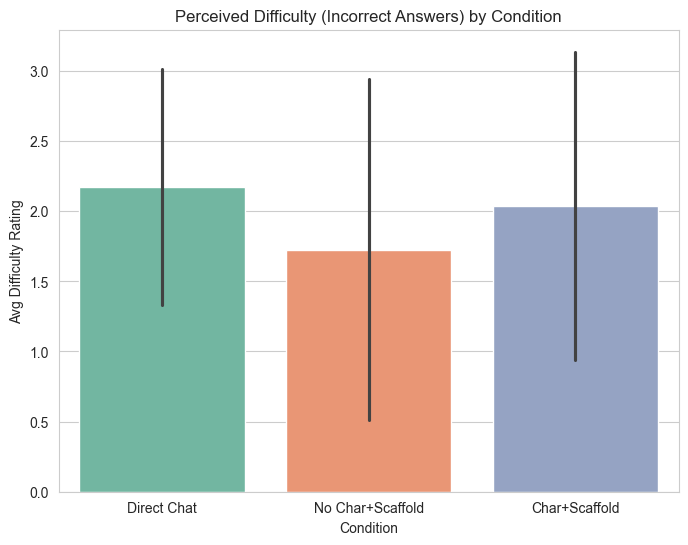

In [40]:
plt.figure(figsize=(8,6))
sns.barplot(
    data=h2_df,
    x='condition_label',
    y='avg_difficulty_incorrect',
    ci='sd',
    palette='Set2'
)
plt.title("Perceived Difficulty (Incorrect Answers) by Condition")
plt.xlabel("Condition")
plt.ylabel("Avg Difficulty Rating")
plt.savefig(figures_dir + "h3_avg_difficulty_incorrect_by_condition.png", dpi=300)
plt.show()




In [42]:
# Plots for difficulty levels performance per condition
import pandas as pd

# -----------------------------
# 1. Load both datasets
# -----------------------------
quiz = pd.read_csv(data_dir+"quiz_questions_updated.csv")
sessions = pd.read_csv(data_dir+"sessions_with_engagement_features_updated.csv")

# -----------------------------
# 2. Identify the 52 dual-session users
# -----------------------------
dual_users = sessions[sessions["has_both"] == True]["user_id"].unique()

# Filter both datasets
quiz = quiz[quiz["user_id"].isin(dual_users)]
sessions = sessions[sessions["user_id"].isin(dual_users)]

# -----------------------------
# 3. Merge quiz + session metadata
# -----------------------------
merged = quiz.merge(
    sessions[["user_id", "session_type", "condition"]],
    on=["user_id", "session_type"],
    how="left"
)

# -----------------------------
# 4. Compute performance by difficulty level
# -----------------------------
difficulty_perf = (
    merged.groupby(["difficulty", "condition"])["is_correct"]
    .mean()
    .reset_index()
)

difficulty_perf["percent_correct"] = difficulty_perf["is_correct"] * 100

# -----------------------------
# 5. Compute performance by question (optional)
# -----------------------------
question_perf = (
    merged.groupby(["question_number", "difficulty", "condition"])["is_correct"]
    .mean()
    .reset_index()
)

# -----------------------------
# 6. Compute avg difficulty of correct/incorrect answers
# -----------------------------
difficulty_summary = merged.groupby(["user_id", "condition"]).apply(
    lambda df: pd.Series({
        "avg_difficulty_correct": df[df["is_correct"] == True]["difficulty"].mean(),
        "avg_difficulty_incorrect": df[df["is_correct"] == False]["difficulty"].mean()
    })
).reset_index()


/var/folders/5w/yxkxqv7j6cn7rlnwhn2dhhl80000gn/T/ipykernel_31954/1259384761.py:51: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  difficulty_summary = merged.groupby(["user_id", "condition"]).apply(


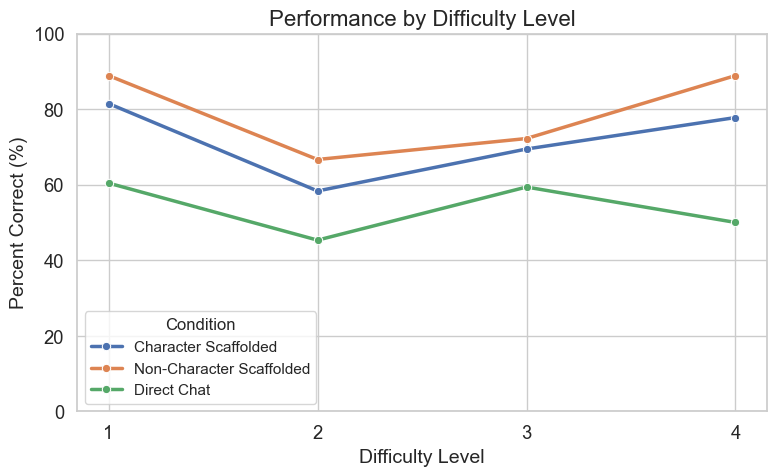

In [44]:

import seaborn as sns
import matplotlib.pyplot as plt


# ----------------------------------------
# Compute performance by difficulty level
# ----------------------------------------
difficulty_perf = (
    merged.groupby(["difficulty", "condition"])["is_correct"]
    .mean()
    .reset_index()
)

difficulty_perf["percent_correct"] = difficulty_perf["is_correct"] * 100

# Map condition numbers to readable labels
condition_labels = {
    1: "Character Scaffolded",
    2: "Non-Character Scaffolded",
    3: "Direct Chat"
}
difficulty_perf["condition_label"] = difficulty_perf["condition"].map(condition_labels)

# ----------------------------------------
# Plot: Performance by Difficulty Level
# ----------------------------------------
sns.set_theme(style="whitegrid", font_scale=1.2)

plt.figure(figsize=(8, 5))

sns.lineplot(
    data=difficulty_perf,
    x="difficulty",
    y="percent_correct",
    hue="condition_label",
    marker="o",
    linewidth=2.5
)

plt.title("Performance by Difficulty Level", fontsize=16)
plt.xlabel("Difficulty Level", fontsize=14)
plt.ylabel("Percent Correct (%)", fontsize=14)
plt.xticks([1, 2, 3, 4])

plt.ylim(0, 100)
plt.legend(title="Condition", fontsize=11, title_fontsize=12)
plt.tight_layout()

# Save high-resolution figure
plt.savefig(figures_dir + "performance_by_difficulty.png", dpi=300)
plt.show()


In [52]:
import pandas as pd

sessions = pd.read_csv(data_dir + "sessions_with_engagement_features_updated.csv")

# Filter to dual-session users
dual_users = sessions[sessions["has_both"] == True]["user_id"].unique()
sessions = sessions[sessions["user_id"].isin(dual_users)]

# Map condition labels
condition_labels = {
    1: "Character Scaffolded",
    2: "Non-Character Scaffolded",
    3: "Direct Chat"
}
sessions["condition_label"] = sessions["condition"].map(condition_labels)
# collapsed - 1 user per session row
user_level = sessions.groupby(["user_id", "condition_label"]).agg(
    quiz_mean=("quiz_percentage", "mean"),
    duration_min=("duration_seconds", lambda x: x.mean() / 60),
    messages=("total_messages", "mean")
).reset_index()


# 2. Now compute summary stats per condition
summary_table = user_level.groupby("condition_label").agg(
    n=("user_id", "count"),
    quiz_mean=("quiz_mean", "mean"),
    quiz_sd=("quiz_mean", "std"),
    duration_mean=("duration_min", "mean"),
    duration_sd=("duration_min", "std"),
    messages_mean=("messages", "mean"),
    messages_sd=("messages", "std")
).reset_index()


summary_table



,condition_label,n,quiz_mean,quiz_sd,duration_mean,duration_sd,messages_mean,messages_sd
0,Character Scaffolded,18,69.444444,17.647603,9.090306,2.729781,21.583333,6.003063
1,Direct Chat,16,53.125000,21.823153,17.394362,1.549326,32.531250,18.715830
2,Non-Character Scaffolded,18,76.666667,13.719887,8.769713,1.806062,21.444444,5.659165


In [59]:


# Load quiz data
quiz = pd.read_csv(data_dir + "quiz_questions_updated.csv")

# Filter to dual-session users
quiz = quiz[quiz["user_id"].isin(dual_users)]

# Merge condition + topic/session info
merged = quiz.merge(
    sessions[["user_id", "session_type", "condition_label"]],
    on=["user_id", "session_type"],
    how="left"
)

# Compute performance by topic + question + difficulty + condition
difficulty_table = (
    merged.groupby(
        ["session_type", "question_number", "difficulty", "condition_label"]
    )["is_correct"]
    .mean()
    .reset_index()
)

# Pivot into wide format
difficulty_pivot = difficulty_table.pivot_table(
    index=["session_type", "question_number", "difficulty"],
    columns="condition_label",
    values="is_correct"
).reset_index()

# Convert to percentages
for col in ["Character Scaffolded", "Non-Character Scaffolded", "Direct Chat"]:
    difficulty_pivot[col] = (difficulty_pivot[col] * 100).round(1)

# Compute overall mean
difficulty_pivot["Overall"] = difficulty_pivot[
    ["Character Scaffolded", "Non-Character Scaffolded", "Direct Chat"]
].mean(axis=1).round(1)

difficulty_pivot



condition_label,session_type,question_number,difficulty,Character Scaffolded,Direct Chat,Non-Character Scaffolded,Overall
0,arraylist,1,1,83.3,62.5,94.4,80.1
1,arraylist,2,2,77.8,37.5,100.0,71.8
2,arraylist,3,2,44.4,56.2,50.0,50.2
3,arraylist,4,2,22.2,31.2,22.2,25.2
4,arraylist,5,4,77.8,50.0,88.9,72.2
5,recursion,1,1,94.4,75.0,94.4,87.9
6,recursion,2,2,88.9,56.2,94.4,79.8
7,recursion,3,3,94.4,75.0,83.3,84.2
8,recursion,4,1,66.7,43.8,77.8,62.8
9,recursion,5,3,44.4,43.8,61.1,49.8


Quiz difficulty: Scaffolded conditions outperform Direct Chat on 6 of 8 question–difficulty pairs.
The largest gains appear at Difficulty 1 and Difficulty 4
Direct Chat only leads on one mid‑level question (Q3‑Difficulty 2), which aligns with the idea that unstructured chat helps with procedural tracing but not conceptual framing.
Non‑Character scaffolding is the top performer on 5 of 8 items.
Character scaffolding performs strongly on high‑difficulty conceptual items (Difficulty 3 and 4).

Qualitative Insights (Student Voice)
Student comments reinforced the quantitative findings. Participants in scaffolded conditions frequently described the experience as clear, structured, and supportive:
“It asked me to explain it back and that really helps.”
“It kept building and asked me to practice.”
“It explained it in a simple way and made sure I understood.”
In contrast, students in the unstructured Direct Chat condition reported greater uncertainty and cognitive friction:
“I didn’t know what questions to ask.”
“It was confusing and I got lost sometimes.”
“It talked at me and didn’t answer in a helpful way.”
These patterns align with the behavioral data: scaffolded conditions produced more stable, calibrated engagement, while Direct Chat led to higher cognitive load and less productive interaction.


Students in Direct Chat describe “cognitive friction,” while students in scaffolded conditions describe “instructional clarity.”
This is not just vibes — it maps directly onto:
Cognitive Load Theory
Metacognitive Calibration
Scaffolding Theory
Self‑regulated learning research


Direct Chat → Cognitive Friction
Students repeatedly express:
uncertainty
confusion
difficulty knowing what to ask
feeling “talked at”
losing the thread
not knowing what the system wanted
Representative quotes:
“I didn’t know what questions to ask.”
“It was confusing and I got lost sometimes.”
“It talked at me and didn’t answer in a helpful way.”
“It was difficult knowing what information was the most significant.”
This aligns with your quantitative findings:
longer response times
lower rapid‑response rates
higher difficulty ratings on incorrect items
greater variance
This is textbook extraneous cognitive load.
2. Scaffolded Conditions → Instructional Clarity + Metacognitive Support
Students describe:
clear steps
helpful examples
being asked to explain back
feeling guided
feeling understood
being able to stay on track
Representative quotes:
“It asked me to explain it back and that really helps.”
“It kept building and asked me to practice.”
“It explained it in a simple way and made sure I understood.”
“It reexplained in a different way when I was confused.”
This matches your quantitative patterns:
more stable response times
higher calibration
lower difficulty variance
smoother engagement
This is classic scaffolding and germane cognitive load.


Qualitative responses reinforced the behavioral findings. Students in scaffolded conditions frequently described the interaction as clear, structured, and supportive (“It asked me to explain it back and that really helps”). In contrast, students in the unstructured Direct Chat condition reported greater uncertainty and cognitive friction (“I didn’t know what questions to ask”; “I got lost sometimes”). These patterns align with cognitive load theory: scaffolding reduced extraneous load and supported metacognitive calibration, while Direct Chat increased ambiguity and response variability.